In [1]:
import numpy as np
import matplotlib.pyplot as plt
from funcs import metrics
from funcs import neural_model

In [2]:
def setMyPlot(figsize):
    plt.figure(figsize=figsize)
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    ax = plt.gca()
    width=2
#     ax.spines['top'].set_linewidth(width)
    ax.spines['bottom'].set_linewidth(width)
    ax.spines['left'].set_linewidth(width)
#     ax.spines['right'].set_linewidth(width)
    ax.spines[['right','top']].set_visible(False)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13) 

In [3]:
# Exp 1: 
# just one neuron population which have intrinsic firing

Pop1 = neural_model.WC_Neuron(Ja = 140.0, Jdp = 110.0, s0=0.011,   
                   taus = 3.9615, taua = 166.80, taudp = 1.8765, taur = 250.2, 
                   x0 = 0.9223, u0 = 0.1, uFlag = 1,UU = 0.03)

PopM = neural_model.WC_Neuron(Ja = 140.0, Jdp = 0.0,
               taus = 5.4210, taua = 500.4, taudp = 1000.0, taur = 225.0, 
               x0 = 0.4796, u0 = 0.4, uFlag = 0)

Jself = 0
Jme = 130
MyNN1 = neural_model.WC_NN([Pop1, PopM], np.array([[Jself,0.0],[Jme, 0.0]]), beta = 0.011, dt = 0.1)
T = 6000
inp_arr = [0.1, 0.0]
MyNN1.init_dynamics(T)
for i in range(MyNN1.Npts):
    MyNN1.update(inp_arr)
    MyNN1.record(i)


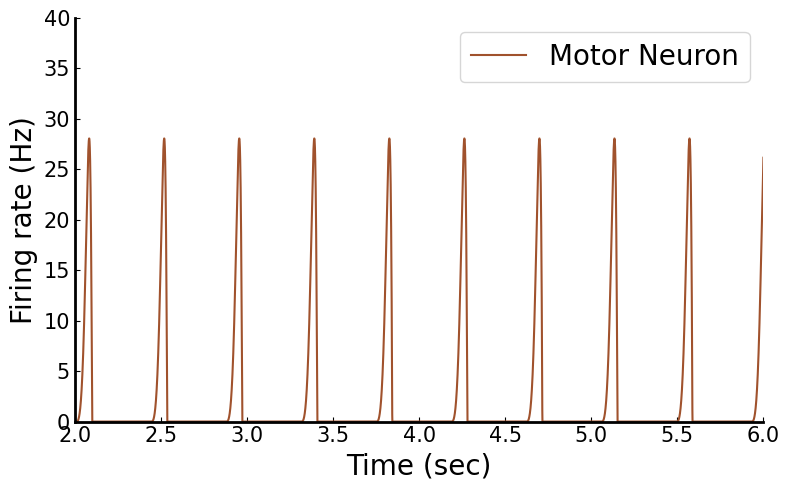

In [4]:
setMyPlot((8,5))
tt = np.linspace(0, T, MyNN1.Npts)
plt.plot(tt/1000, MyNN1.marr[0]*1000, label = 'Motor Neuron',color = 'sienna')
plt.xlabel('Time (sec)',fontsize =20)
plt.ylabel('Firing rate (Hz)', fontsize = 20)
plt.xlim([2,6])
plt.ylim([0.0, 40])
plt.legend(fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.tight_layout()

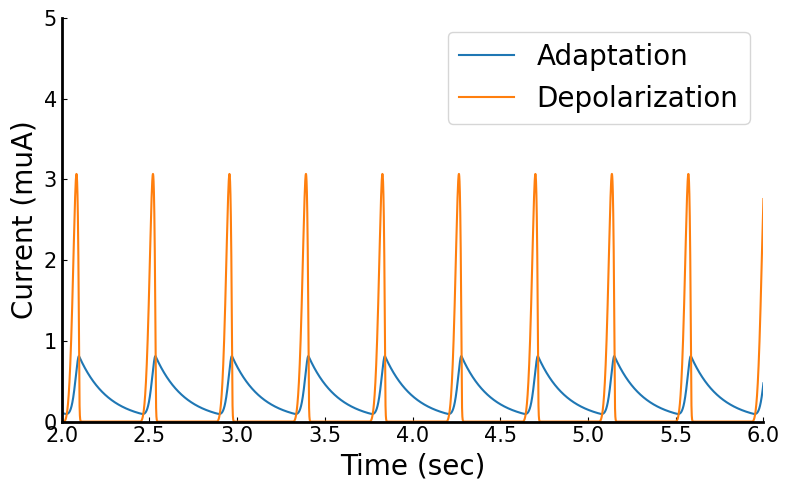

In [5]:
setMyPlot((8,5))
tt = np.linspace(0, T, MyNN1.Npts)
plt.plot(tt/1000, MyNN1.aarr[0], label = 'Adaptation')
plt.plot(tt/1000, MyNN1.dparr[0], label = 'Depolarization')
plt.xlabel('Time (sec)',fontsize =20)
plt.ylabel('Current (muA)', fontsize = 20)
plt.xlim([2,6])
plt.ylim([0.0, 5.0])
plt.legend(fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.tight_layout()

In [6]:
# Exp 2:
# adding inhibitory population, form an E-I loop

Pop2 = neural_model.WC_Neuron(Ja = 180.0, Jdp = 0.0, s0=0.01,
               taus = 5.4210, taua = 62.55, taudp = 1000.0, taur = 225.0, 
               x0 = 0.4796, u0 = 0.4, uFlag = 0)

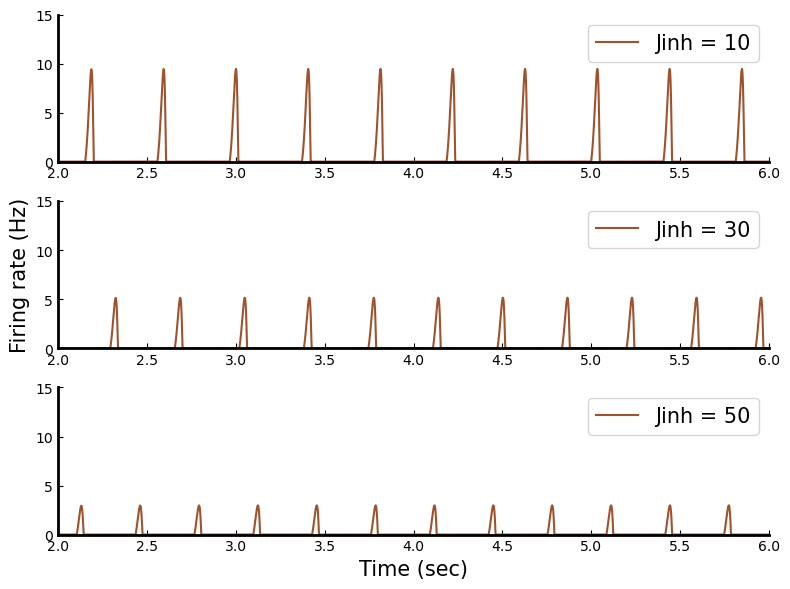

In [7]:
ind = 0
Jext = 26
Jinh = 10
Jselfi = 0
inp_arr = [0.3,0.3, 0.0]
Jme = 65
Jmi = 100
fig, axs = plt.subplots(3, figsize = (8,6))
width=2
for Jinh in [10.0,30.0,50.0]:
    MyNN2 = neural_model.WC_NN([Pop1,Pop2,PopM], np.array([[Jself,-Jinh, 0.0],[Jext, -Jselfi, 0.0],
                                             [Jme, -Jmi, 0.0]]), beta = 0.011, dt = 0.1)
    T = 6000
    MyNN2.init_dynamics(T)
    for i in range(MyNN2.Npts):
        MyNN2.update(inp_arr)
        MyNN2.record(i)
    tt = np.linspace(0, T, MyNN2.Npts)
    axs[ind].plot(tt/1000, MyNN2.marr[2]*1000, label = 'Jinh = '+str(int(Jinh)),color = 'sienna')
    axs[ind].set_xlim([2,6])
    axs[ind].set_ylim([0.0, 15])
    axs[ind].legend(fontsize = 15)
#     axs[ind].spines['top'].set_linewidth(width)
    axs[ind].spines['bottom'].set_linewidth(width)
    axs[ind].spines['left'].set_linewidth(width)
#     axs[ind].spines['right'].set_linewidth(width)
    axs[ind].spines[['right','top']].set_visible(False)
    ind += 1
axs[2].set_xlabel('Time (sec)',fontsize =15)
axs[1].set_ylabel('Firing rate (Hz)', fontsize = 15)
plt.tight_layout()


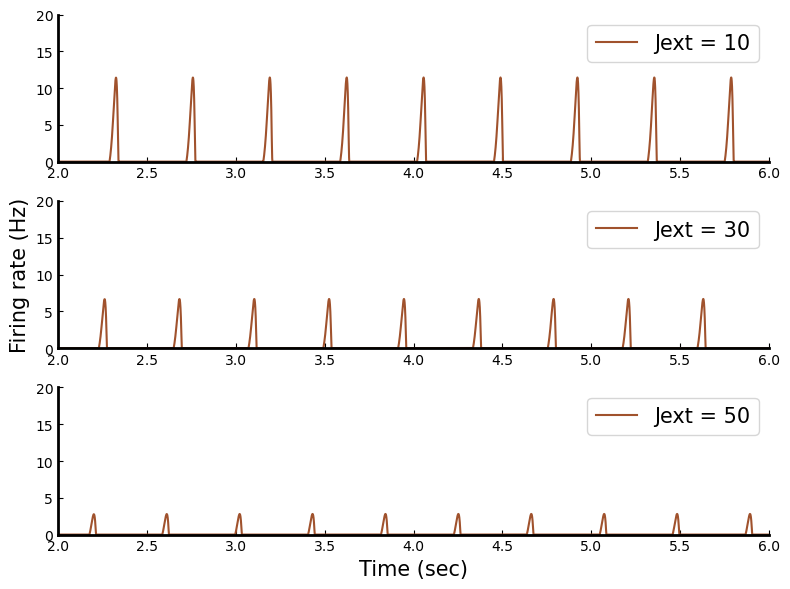

In [8]:
ind = 0

fig, axs = plt.subplots(3, figsize = (8,6))
width=2
Jext = 20
Jinh = 5
Jselfi = 0
inp_arr = [0.3,0.3, 0.0]
Jme = 50
Jmi = 100
for Jext in [10.0,30.0,50.0]:
    MyNN2 = neural_model.WC_NN([Pop1,Pop2,PopM], np.array([[Jself,-Jinh, 0.0],[Jext, -Jselfi, 0.0],
                                             [Jme, -Jmi, 0.0]]), beta = 0.011, dt = 0.2)
    T = 6000
    MyNN2.init_dynamics(T)
    for i in range(MyNN2.Npts):
        MyNN2.update(inp_arr)
        MyNN2.record(i)
    tt = np.linspace(0, T, MyNN2.Npts)
    axs[ind].plot(tt/1000, MyNN2.marr[2]*1000, label = 'Jext = '+str(int(Jext)),color = 'sienna')
    axs[ind].set_xlim([2,6])
    axs[ind].set_ylim([0.0, 20])
    axs[ind].legend(fontsize = 15)
#     axs[ind].spines['top'].set_linewidth(width)
    axs[ind].spines['bottom'].set_linewidth(width)
    axs[ind].spines['left'].set_linewidth(width)
#     axs[ind].spines['right'].set_linewidth(width)
    axs[ind].spines[['right','top']].set_visible(False)
    ind += 1
axs[2].set_xlabel('Time (sec)',fontsize =15)
axs[1].set_ylabel('Firing rate (Hz)', fontsize = 15)
plt.tight_layout()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


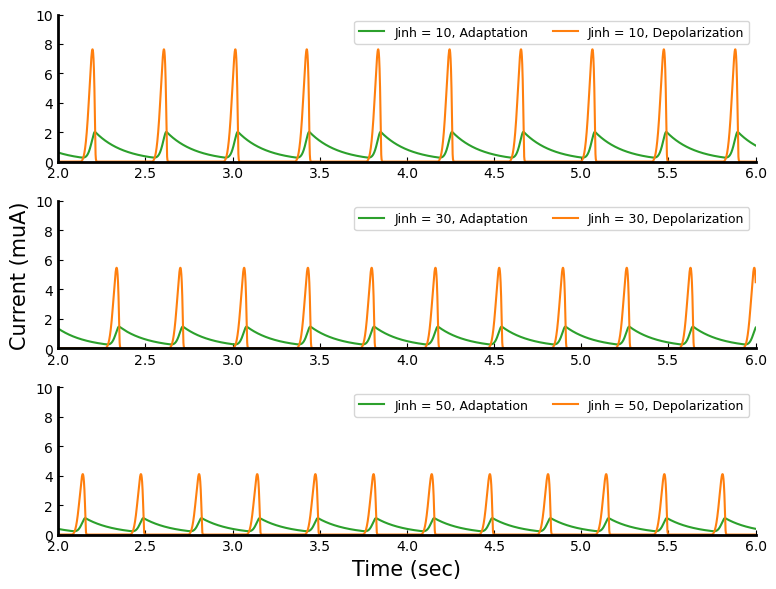

In [10]:
ind = 0

fig, axs = plt.subplots(3, figsize = (8,6))
width=2
Jext = 26
for Jinh in [10.0,30.0,50.0]:
    MyNN2 = neural_model.WC_NN([Pop1,Pop2,PopM], np.array([[Jself,-Jinh, 0.0],[Jext, -Jselfi, 0.0],
                                             [Jme, -Jmi, 0.0]]), beta = 0.011, dt = 0.2)
    T = 6000
    MyNN2.init_dynamics(T)
    for i in range(MyNN2.Npts):
        MyNN2.update(inp_arr)
        MyNN2.record(i)
    tt = np.linspace(0, T, MyNN2.Npts)
    axs[ind].plot(tt/1000, MyNN2.aarr[0], label = 'Jinh = '+str(int(Jinh))+', Adaptation',color='tab:green')
    axs[ind].plot(tt/1000, MyNN2.dparr[0], label = 'Jinh = '+str(int(Jinh))+', Depolarization',color='tab:orange')
    axs[ind].set_xlim([2,6])
    axs[ind].set_ylim([0.0, 10])
    axs[ind].legend(fontsize = 9,ncols=2)
#     axs[ind].spines['top'].set_linewidth(width)
    axs[ind].spines['bottom'].set_linewidth(width)
    axs[ind].spines['left'].set_linewidth(width)
#     axs[ind].spines['right'].set_linewidth(width)
    axs[ind].spines[['right','top']].set_visible(False)
    ind += 1
axs[2].set_xlabel('Time (sec)',fontsize =15)
axs[1].set_ylabel('Current (muA)', fontsize = 15)
plt.tight_layout()
